# Phase 5: Explainable AI (XAI) using SHAP
This notebook explains the predictions of our best baseline model (XGBoost) using SHAP (SHapley Additive exPlanations) on the updated datasets (containing the simulated noisy milestone features).


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
shap.initjs()


C:\Users\NDHoang\PycharmProjects\ML-_Project_Autism_Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the noisy simulated datasets (containing the 3 developmental milestone features)
train = pd.read_csv("../data/processed/train_cleaned.csv")
target_col = 'Class/ASD'
X = train.drop(columns=[target_col])
y = train[target_col]
print(f"Data Loaded successfully. Features shape: {X.shape}, Target shape: {y.shape}")


Data Loaded successfully. Features shape: (23743, 32), Target shape: (23743,)


In [3]:
# Train the XGBoost Classifier
model = xgb.XGBClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=5, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    eval_metric='logloss', 
    random_state=42
)
model.fit(X, y)
print("XGBoost Model Trained successfully!")


XGBoost Model Trained successfully!


In [4]:
# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
print("SHAP values computed successfully!")


SHAP values computed successfully!


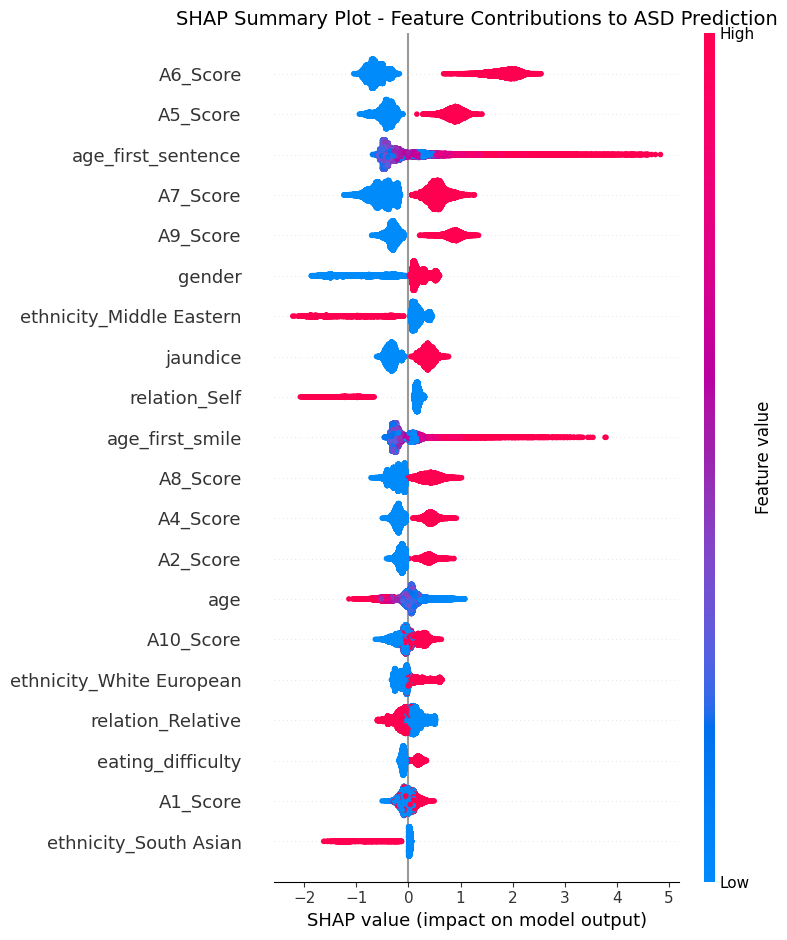

In [5]:
# 1. Summary Plot - shows global feature contribution
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.title("SHAP Summary Plot - Feature Contributions to ASD Prediction", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary_plot.png")
plt.show()


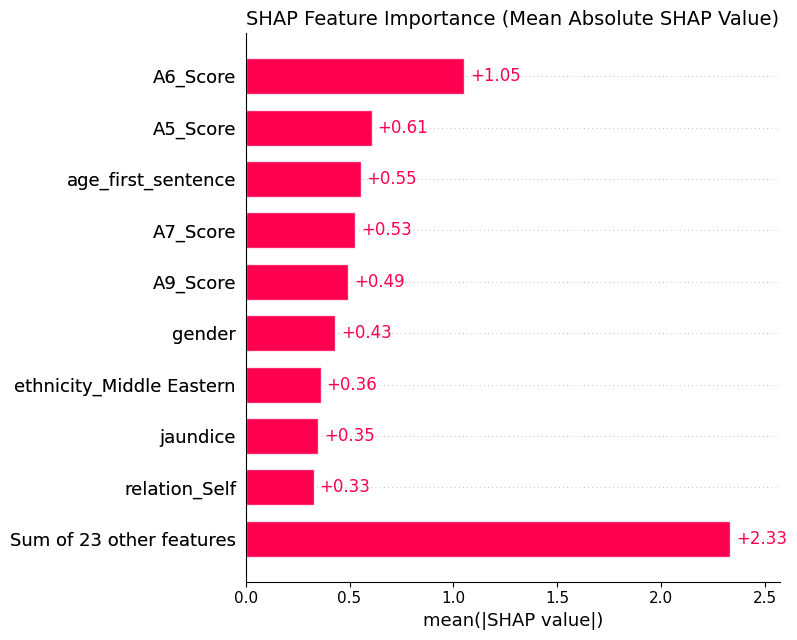

In [6]:
# 2. Bar Plot - shows average feature importance magnitude
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, show=False)
plt.title("SHAP Feature Importance (Mean Absolute SHAP Value)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_bar_plot.png")
plt.show()


In [7]:
# Find a positive (ASD = 1) and negative (ASD = 0) patient to explain locally
asd_indices = np.where(y == 1)[0]
normal_indices = np.where(y == 0)[0]
print(f"ASD index sample: {asd_indices[0]}, Normal index sample: {normal_indices[0]}")


ASD index sample: 1, Normal index sample: 0


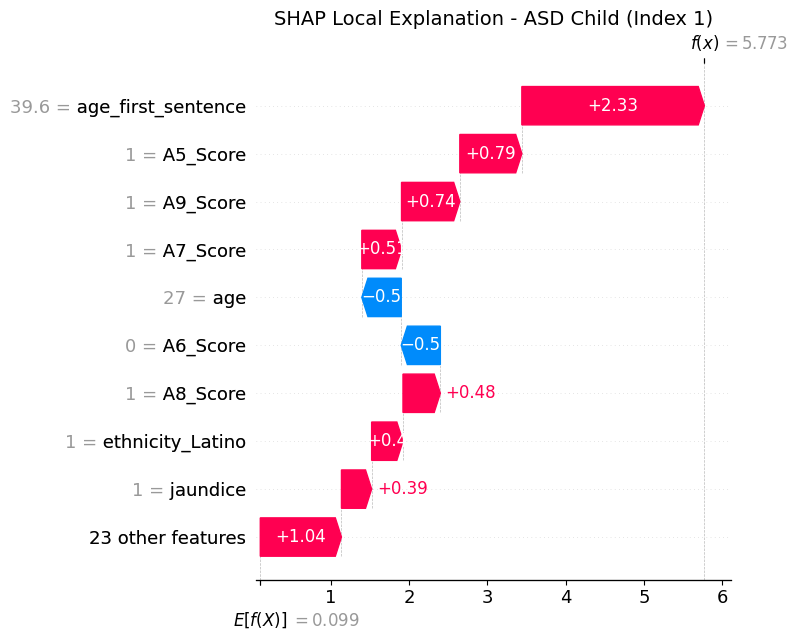

In [8]:
# 3. Local Explanation for an ASD patient (first index)
plt.figure(figsize=(10, 4))
shap.plots.waterfall(shap_values[asd_indices[0]], show=False)
plt.title(f"SHAP Local Explanation - ASD Child (Index {asd_indices[0]})", fontsize=14)
plt.tight_layout()
plt.savefig("shap_waterfall_asd.png")
plt.show()


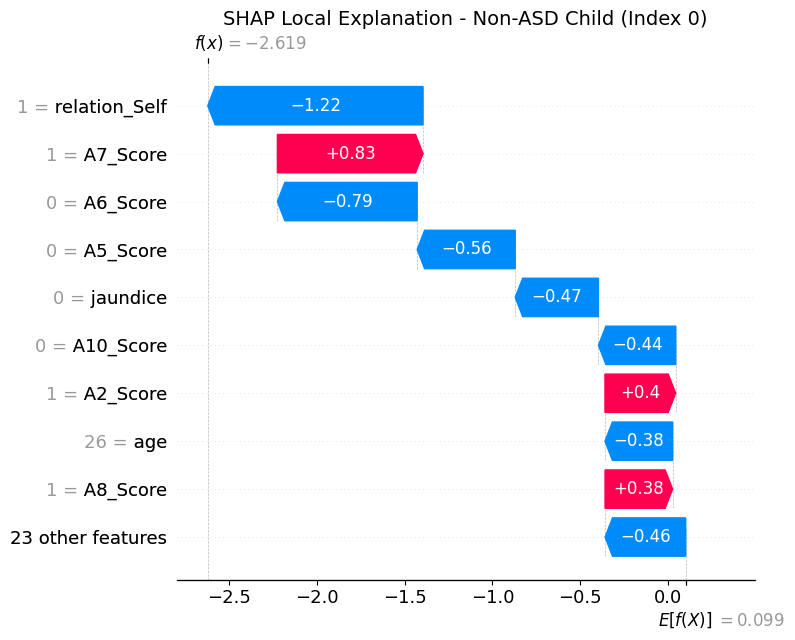

In [9]:
# 4. Local Explanation for a Non-ASD patient (first index)
plt.figure(figsize=(10, 4))
shap.plots.waterfall(shap_values[normal_indices[0]], show=False)
plt.title(f"SHAP Local Explanation - Non-ASD Child (Index {normal_indices[0]})", fontsize=14)
plt.tight_layout()
plt.savefig("shap_waterfall_normal.png")
plt.show()
